# Test: Decomposed Q-Network for RL Resistance MM

Trains a 3-layer CNN that predicts per-key Q-values from visual input (frames)
and current key state.  Uses an **independent Q-function** where:

$$Q(s, a) = \sum_k Q_k(s, a_k)$$

- Each key gets its own Q-value head (`Q_k`)
- Total Q is the sum of individual key contributions
- Pairwise interaction terms to be added later (see `modeling/docs/pairwise_interactions.md`)

We will know our data is meaningful if this CNN can perform better than random actions in test matches.

In [2]:
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add project root so we can import reward
PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from reward import compute_rewards_for_episode, RewardWeights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Configuration

In [3]:
# --- Paths ---
DATA_DIR = PROJECT_ROOT / "data" / "test_won_in_area2"
TRAINING_CSV = DATA_DIR / "training_data.csv"
SCREENS_DIR = Path("../input_capture/re_resistance_captures/won_in_area2/screens")

# --- Key columns (action space) ---
# Exclude: timestamp, time_burn_delta, frame (not actions)
KEY_COLUMNS = [
    "mouse_left", "mouse_middle", "mouse_right",
    "key_w", "key_a", "key_s", "key_d",
    "key_q", "key_e", "key_r", "key_f", "key_v", "key_m",
    "key_1", "key_2", "key_3", "key_4",
    "key_space", "key_up", "key_down", "key_left", "key_right",
]
NUM_KEYS = len(KEY_COLUMNS)

# Mouse position is continuous state, not a binary action
MOUSE_COLUMNS = ["mouse_x", "mouse_y", "mouse_dx", "mouse_dy"]

# --- Hyperparameters ---
IMG_SIZE = (84, 84)       # Resize frames for CNN input
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
GAMMA = 0.99              # Discount factor
NUM_EPOCHS = 20
MAX_EARLY_STOP_EPOCHS = 5  # Max extra epochs for early stopping
TRAIN_SPLIT = 0.8

print(f"Action space: {NUM_KEYS} binary keys")
print(f"Training CSV: {TRAINING_CSV}")

Action space: 22 binary keys
Training CSV: C:\Users\Py Torch\Documents\GitHub\Sillyness\RL_Resistance_MM\modeling\data\test_won_in_area2\training_data.csv


## 2. Load data & compute rewards

In [4]:
df = pd.read_csv(TRAINING_CSV)
print(f"Loaded {len(df)} frames, columns: {list(df.columns)}")

# Compute per-frame rewards using the naive equal-weight reward function
rows = df.to_dict(orient="records")
rewards = compute_rewards_for_episode(rows)
df["reward"] = rewards

# Normalize rewards to zero mean, unit variance
reward_mean = df["reward"].mean()
reward_std = df["reward"].std()
df["reward"] = (df["reward"] - reward_mean) / (reward_std + 1e-8)
print(f"\nReward normalized: mean={reward_mean:.4f}, std={reward_std:.4f}")

# Compute discounted return (target for Q-learning)
returns = np.zeros(len(df))
running = 0.0
for t in reversed(range(len(df))):
    running = df["reward"].iloc[t] + GAMMA * running
    returns[t] = running
df["discounted_return"] = returns

print(f"\nReward stats (normalized):")
print(df["reward"].describe())
print(f"\nDiscounted return stats:")
print(df["discounted_return"].describe())

Loaded 9952 frames, columns: ['frame', 'timestamp', 'mouse_x', 'mouse_y', 'mouse_left', 'mouse_middle', 'mouse_right', 'mouse_dx', 'mouse_dy', 'key_w', 'key_a', 'key_s', 'key_d', 'key_q', 'key_e', 'key_r', 'key_f', 'key_v', 'key_m', 'key_1', 'key_2', 'key_3', 'key_4', 'key_space', 'key_up', 'key_down', 'key_left', 'key_right', 'time_burn_delta', 'bio_energy', 's1_health', 's1_infection', 's2_health', 's2_infection', 's3_health', 's3_infection', 's4_health', 's4_infection', 'camera_status']

Reward normalized: mean=1.2773, std=242.1241

Reward stats (normalized):
count    9.952000e+03
mean    -9.393165e-18
std      1.000000e+00
min     -2.280008e+01
25%     -5.275569e-03
50%     -1.145455e-03
75%      2.984659e-03
max      2.385357e+01
Name: reward, dtype: float64

Discounted return stats:
count    9952.000000
mean       -0.002410
std         1.602518
min        -3.936826
25%        -0.418730
50%        -0.110536
75%         0.236698
max        22.861909
Name: discounted_return, dtype: 

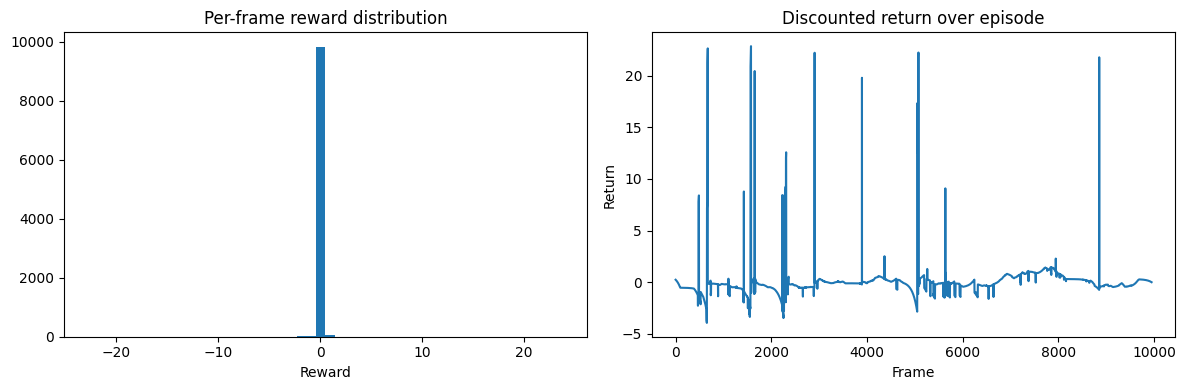

In [5]:
# Quick reward distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["reward"], bins=50)
axes[0].set_title("Per-frame reward distribution")
axes[0].set_xlabel("Reward")
axes[1].plot(df["discounted_return"].values)
axes[1].set_title("Discounted return over episode")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Return")
plt.tight_layout()
plt.show()

## 3. Dataset

In [6]:
class ResistanceDataset(Dataset):
    """Dataset that loads a frame image + key state and returns the Q target."""

    def __init__(self, dataframe: pd.DataFrame, screens_dir: Path, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.screens_dir = screens_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame_num = int(row["frame"])

        # Load frame image
        img_path = self.screens_dir / f"frame_{frame_num:06d}.jpg"
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Key state vector (binary actions taken at this frame)
        keys = torch.tensor([row[k] for k in KEY_COLUMNS], dtype=torch.float32)

        # Mouse state (continuous)
        mouse = torch.tensor([row[k] for k in MOUSE_COLUMNS], dtype=torch.float32)
        # Normalise mouse_x/y to [0, 1]
        mouse[0] /= 1920.0
        mouse[1] /= 1080.0
        # Normalise mouse_dx/dy (clamp large values)
        mouse[2] = torch.clamp(mouse[2] / 100.0, -1.0, 1.0)
        mouse[3] = torch.clamp(mouse[3] / 100.0, -1.0, 1.0)

        # Target: discounted return for this frame
        target = torch.tensor(row["discounted_return"], dtype=torch.float32)

        return image, keys, mouse, target

In [7]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),              # [0, 255] -> [0, 1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],     # ImageNet stats
        std=[0.229, 0.224, 0.225],
    ),
])

# Filter to frames that have corresponding images
valid_frames = df["frame"].apply(
    lambda f: (SCREENS_DIR / f"frame_{int(f):06d}.jpg").exists()
)
df_valid = df[valid_frames].copy()
print(f"Frames with images: {len(df_valid)} / {len(df)}")

# Train/val split (temporal — no shuffling across time)
split_idx = int(len(df_valid) * TRAIN_SPLIT)
df_train = df_valid.iloc[:split_idx]
df_val = df_valid.iloc[split_idx:]

train_ds = ResistanceDataset(df_train, SCREENS_DIR, transform=transform)
val_ds = ResistanceDataset(df_val, SCREENS_DIR, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Frames with images: 9952 / 9952
Train: 7961, Val: 1991


## 4. Decomposed Q-Network

Architecture:
- **3-layer CNN** extracts visual features from the frame
- Concatenated with mouse state to form a state embedding
- **Per-key Q heads**: N linear outputs, each predicting `Q_k(s, a_k)` for one key
- Total: `Q(s, a) = sum(Q_k * a_k)`

In [13]:
class DecomposedQNetwork(nn.Module):
    """Q-function decomposed into independent per-key values."""

    def __init__(self, num_keys: int, mouse_dim: int = 4):
        super().__init__()
        self.num_keys = num_keys

        # --- 3-layer CNN for visual features ---
        # Input: 3 x 84 x 84
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=8, stride=4),   # -> 32 x 20 x 20
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),  # -> 64 x 9 x 9
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # -> 64 x 7 x 7
            nn.ReLU(),
        )

        # CNN output size: 64 * 7 * 7 = 3136
        cnn_out = 64 * 7 * 7

        # --- State embedding: CNN features + mouse state ---
        state_dim = 256
        self.state_fc = nn.Sequential(
            nn.Linear(cnn_out + mouse_dim, 512),
            nn.ReLU(),
            nn.Linear(512, state_dim),
            nn.ReLU(),
        )

        # --- Per-key Q heads ---
        # Each key gets a Q value: Q_k(s) — value of pressing key k in state s
        self.key_heads = nn.Linear(state_dim, num_keys)

    def forward(self, image: torch.Tensor, keys: torch.Tensor, mouse: torch.Tensor) -> torch.Tensor:
        """Compute Q(s, a) for the given state-action pair.

        Args:
            image: (B, 3, 84, 84) frame tensor
            keys:  (B, num_keys)   binary action vector
            mouse: (B, 4)          normalised mouse state

        Returns:
            q_total: (B,) scalar Q-value for each sample
        """
        # Visual features
        x = self.cnn(image)                        # (B, 64, 7, 7)
        x = x.view(x.size(0), -1)                  # (B, 3136)

        # State embedding
        state = self.state_fc(torch.cat([x, mouse], dim=1))  # (B, 256)

        # Per-key Q values, masked by which keys are actually pressed
        q_keys = self.key_heads(state)              # (B, num_keys)
        q_total = (q_keys * keys).sum(dim=1)        # (B,)

        return q_total

    def get_key_q_values(self, image: torch.Tensor, mouse: torch.Tensor) -> torch.Tensor:
        """Get Q-value for each key independently (for action selection).

        Returns:
            (B, num_keys) per-key Q-values
        """
        x = self.cnn(image)
        x = x.view(x.size(0), -1)
        state = self.state_fc(torch.cat([x, mouse], dim=1))
        return self.key_heads(state)

In [18]:
model = DecomposedQNetwork(num_keys=NUM_KEYS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 1,821,110
DecomposedQNetwork(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (state_fc): Sequential(
    (0): Linear(in_features=3140, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (key_heads): Linear(in_features=256, out_features=22, bias=True)
)


## 5. Training loop

In [19]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for images, keys, mouse, targets in loader:
        images = images.to(device)
        keys = keys.to(device)
        mouse = mouse.to(device)
        targets = targets.to(device)

        q_pred = model(images, keys, mouse)
        loss = F.mse_loss(q_pred, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    for images, keys, mouse, targets in loader:
        images = images.to(device)
        keys = keys.to(device)
        mouse = mouse.to(device)
        targets = targets.to(device)

        q_pred = model(images, keys, mouse)
        loss = F.mse_loss(q_pred, targets)

        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

In [20]:
train_losses = []
val_losses = []

### Training Strategy

#### Fixed epochs

In [ ]:
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Training"):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = eval_epoch(model, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    tqdm.write(f"Epoch {epoch:3d}/{NUM_EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

print("\nTraining complete.")

#### Early stopping

In [21]:
# Train until loss increases or MAX_EARLY_STOP_EPOCHS is reached
start = 1
end = start+ int(1e6) + MAX_EARLY_STOP_EPOCHS

num_worse_epochs = 0
for epoch in tqdm(range(start, end), desc="Training (early stop)"):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = eval_epoch(model, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    tqdm.write(f"Epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if len(val_losses) >= NUM_EPOCHS and val_loss > val_losses[-2]:
        num_worse_epochs += 1
        if num_worse_epochs > MAX_EARLY_STOP_EPOCHS:
            tqdm.write(f"Validation loss increased ({val_losses[-2]:.4f} -> {val_loss:.4f}), stopping.")
            break

print(f"\nStopped after {len(train_losses)} total epochs.")

Training (early stop):   0%|          | 1/1000005 [02:05<34802:53:24, 125.29s/it]

Epoch   1  train_loss=3.1008  val_loss=0.3706


Training (early stop):   0%|          | 2/1000005 [04:09<34556:25:29, 124.40s/it]

Epoch   2  train_loss=3.0731  val_loss=0.3703


Training (early stop):   0%|          | 3/1000005 [06:11<34366:29:42, 123.72s/it]

...

Epoch  29  train_loss=2.8719  val_loss=0.3970


Training (early stop):   0%|          | 30/1000005 [56:46<31243:07:26, 112.48s/it]

Epoch  30  train_loss=2.8401  val_loss=0.3877


Training (early stop):   0%|          | 30/1000005 [58:39<32586:31:11, 117.31s/it]

Epoch  31  train_loss=2.8422  val_loss=0.4411
Validation loss increased (0.3877 -> 0.4411), stopping.

Stopped after 31 total epochs.


## 6. Results

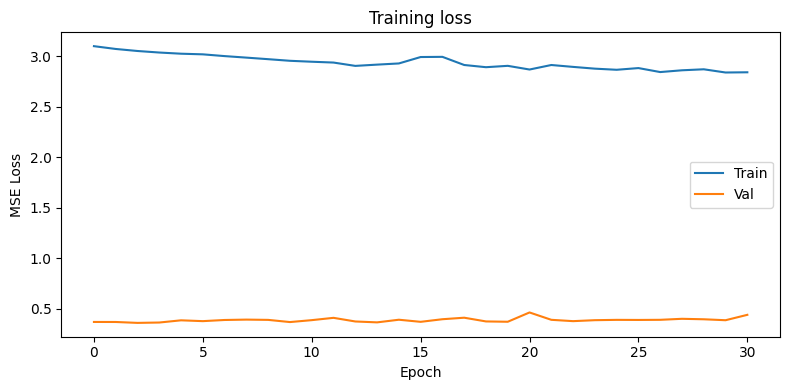

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train")
ax.plot(val_losses, label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training loss")
ax.legend()
plt.tight_layout()
plt.show()

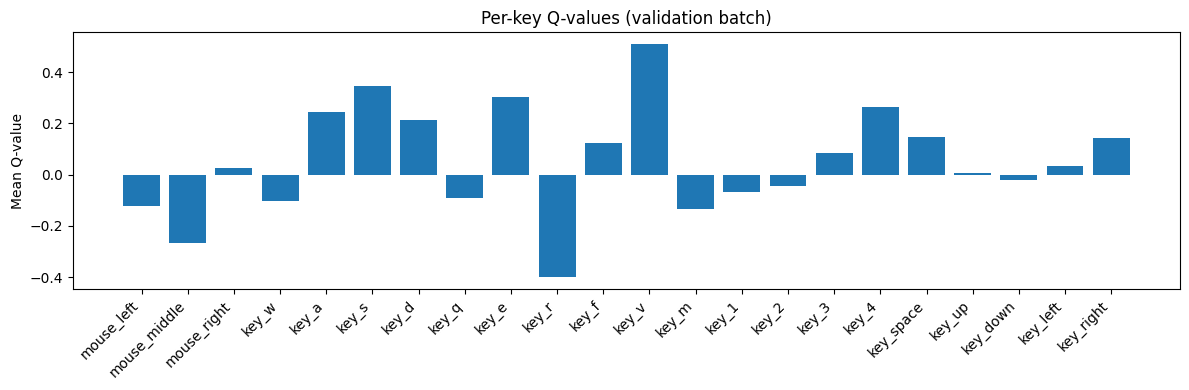

In [ ]:
# Inspect per-key Q-values on a few validation samples
model.eval()
sample_images, sample_keys, sample_mouse, sample_targets = next(iter(val_loader))
sample_images = sample_images.to(device)
sample_mouse = sample_mouse.to(device)

with torch.no_grad():
    key_q = model.get_key_q_values(sample_images, sample_mouse).cpu()

# Show average Q per key across the batch
mean_q = key_q.mean(dim=0)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(NUM_KEYS), mean_q.numpy())
ax.set_xticks(range(NUM_KEYS))
ax.set_xticklabels(KEY_COLUMNS, rotation=45, ha="right")
ax.set_ylabel("Mean Q-value")
ax.set_title("Per-key Q-values (validation batch)")
plt.tight_layout()
plt.show()

In [ ]:
# Save model checkpoint
ckpt_path = PROJECT_ROOT / "checkpoints"
ckpt_path.mkdir(exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "key_columns": KEY_COLUMNS,
    "num_keys": NUM_KEYS,
}, ckpt_path / "cnn_v1.pt")
print(f"Saved checkpoint to {ckpt_path / 'decomposed_q_v0.pt'}")

Saved checkpoint to C:\Users\Py Torch\Documents\GitHub\Sillyness\RL_Resistance_MM\modeling\checkpoints\decomposed_q_v0.pt
